# Ampere Analysis Notebook

This notebook demonstrates how to load HPL traces using the `ampere` library and visualize energy consumption.
Now running on **Arkouda** for scalable server-side processing.

In [9]:
A="/Users/hom/Documents/ampere/examples/arithmetic-square-wave-04-29-26-13:50:09/cycles-45"
B="/Users/hom/Documents/ampere/examples/arithmetic-square-wave-05-05-26-10:44:34/cycles-45"
A_TITLE = "Control Run"
B_TITLE = "Test Run"

TRACES = [A, B]


In [10]:
from IPython.display import display
import re
from ampere import Ensemble, Metric, MetricConfig, MetricType, AmpereSession, Visualizer, connect
import arkouda as ak
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
# Connect to Arkouda (registers cleanup automatically)
connect(server="localhost", port=5555)

/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/arkouda/core/client.py:860: RuntimeWarning: Version mismatch between client (2026.02.02+40.gec39a6ec8) and server (2026.02.02.1); this may cause some commands to fail or behave incorrectly! Updating arkouda is strongly recommended.
  warnings.warn(
connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [11]:
for trace in TRACES:
    if not glob(os.path.join(trace, "*.csv")):
        os.system(f"cd {trace} && ~/otf2csv ./traces.otf2")


Converting trace at ./traces.otf2 to CSV...










Processing Process Orphan thread 3:   0%|          | 0/16 [00:00<?, ?event/s]








Processing Process Orphan thread 4:   0%|          | 0/16 [00:00<?, ?event/s]










Processing Process Orphan thread 6:   0%|          | 0/16 [00:00<?, ?event/s]









Processing Process Orphan thread 5:   0%|          | 0/16 [00:00<?, ?event/s]






Processing Process Orphan thread 2:   0%|          | 0/16 [00:00<?, ?event/s]











Processing Process Orphan thread 7:   0%|          | 0/16 [00:00<?, ?event/s]












Processing Process Orphan thread 8:   0%|          | 0/16 [00:00<?, ?event/s]




Processing Process Master thread:   0%|          | 0/4 [00:00<?, ?event/s]

Processing Process :   0%|          | 0/19976 [00:00<?, ?event/s]



Processing Process :   0%|          | 0/19976 [00:00<?, ?event/s]


Processing Process :   0%|          | 0/19976 [00:00<?, ?event/s]





Processing Process :   0%|          | 0/19976 [00:00<?, ?event/s]







                             


Reading completed in 0.83 seconds.
Writing completed in 0.01 seconds.
All done in 0.84 seconds (0.01 minutes).


In [12]:
# Define Metric Configs
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*violation.*"): MetricConfig(MetricType.CUMULATIVE),
    re.compile(r".*rocm.*clk.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-9),
}

# Define Topology Resolver
def my_hpc_topology(metric_name, ranks):
    # if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    # if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=1' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=3' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    return ranks

In [13]:
ranks = [f"MPI Rank {i}" for i in range(8)]
ranks = ["Process"]
topo = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths([A, B], topo, configs)


Loading Runs: 100%|██████████| 2/2 [00:00<00:00,  3.08it/s]


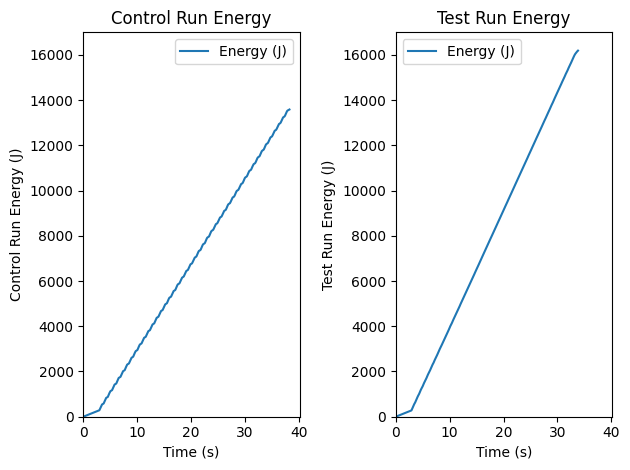

In [14]:
# Graph the energy over time for each GPU
fig, axs = plt.subplots(1, 2)

y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::energy_count:device=4"]
df = ak.DataFrame({
    "Timestamp": y.times,
    "Energy (J)": y.values
})

df = df.to_pandas()
initial_energy = df["Energy (J)"][0]
df["Energy (J)"] = df["Energy (J)"] - initial_energy

df.plot.line(x="Timestamp", y="Energy (J)", title=f"{A_TITLE} Energy", xlabel="Time (s)", ylabel=f"{A_TITLE} Energy (J)", ax=axs[0])

y = ensemble.runs[1].nodes[0].metrics["A2rocm_smi:::energy_count:device=4"]
df = ak.DataFrame({
    "Timestamp": y.times,
    "Energy (J)": y.values
})

df = df.to_pandas()
initial_energy = df["Energy (J)"][0]
df["Energy (J)"] = df["Energy (J)"] - initial_energy
df.plot.line(x="Timestamp", y="Energy (J)", title=f"{B_TITLE} Energy", xlabel="Time (s)", ylabel=f"{B_TITLE} Energy (J)", ax=axs[1])

max_y = max(axs[0].get_ylim()[1], axs[1].get_ylim()[1])
axs[0].set_ylim(0, max_y)
axs[1].set_ylim(0, max_y)

max_x = max(axs[0].get_xlim()[1], axs[1].get_xlim()[1])
axs[0].set_xlim(0, max_x)
axs[1].set_xlim(0, max_x)


plt.tight_layout()
plt.show()

In [15]:

def numerical_derivative(func, h=0.001):
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

# Derive instantaneous power from cumulative energy
def calc_power(energy_metric):
    t = energy_metric.times.to_ndarray()
    e = energy_metric.values.to_ndarray()
    f = lambda x: np.interp(x, t, e)
    f = numerical_derivative(f)
    # dt = t[1:] - t[:-1]
    # de = e[1:] - e[:-1]
    # power = de / dt
    power = f(t)
    # power = ak.where((power < 0) | (dt <= 0), 0.0, power)
    return Metric("power", ak.array(t), ak.array(power), MetricConfig(MetricType.INSTANTANEOUS))

for d in [0, 2, 4, 6]:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        calc_power,
        f"A2rocm_smi:::energy_count:device={d}"
    )


Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...


0.20301066276395568
0.13549302435563962


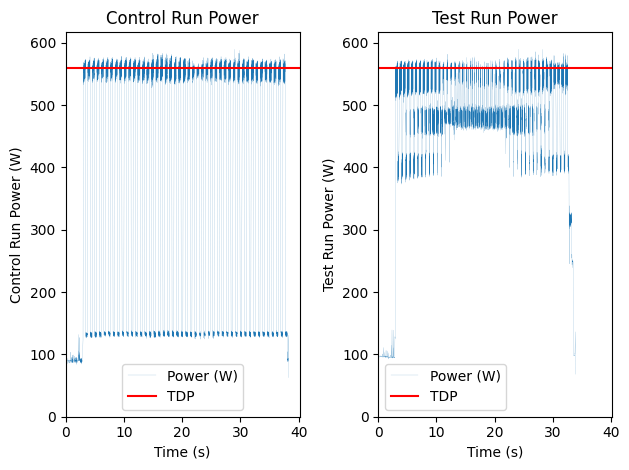

In [16]:
fig, axs = plt.subplots(1, 2)

# Graph the energy over time for each GPU
y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::inst_power:device=0"]
df = ak.DataFrame({
    "Timestamp": y.times,
    "Power (W)": y.values
})

df = df.to_pandas()
df_a = df.copy()

print(len(df[df['Power (W)'] > 560]) / len(df['Power (W)']))

df.plot.line(x="Timestamp", y="Power (W)", title=f"{A_TITLE} Power", xlabel="Time (s)", ylabel=f"{A_TITLE} Power (W)", ax=axs[0], lw=0.1)
# df.plot.scatter(x="Timestamp", y="Power (W)", title=f"{A_TITLE} Power", xlabel="Time (s)", ylabel=f"{A_TITLE} Power (W)", ax=axs[0])
axs[0].axhline(560, color='red', label="TDP")
axs[0].legend()

y = ensemble.runs[1].nodes[0].metrics["A2rocm_smi:::inst_power:device=0"]
df = ak.DataFrame({
    "Timestamp": y.times,
    "Power (W)": y.values
})
df = df.to_pandas()
df_b = df
print(len(df[df['Power (W)'] > 560]) / len(df['Power (W)']))
df.plot.line(x="Timestamp", y="Power (W)", title=f"{B_TITLE} Power", xlabel="Time (s)", ylabel=f"{B_TITLE} Power (W)", ax=axs[1], lw=0.1)
# df.plot.scatter(x="Timestamp", y="Power (W)", title=f"{B_TITLE} Power", xlabel="Time (s)", ylabel=f"{B_TITLE} Power (W)", ax=axs[1])
axs[1].axhline(560, color='red', label="TDP")
axs[1].legend()

max_y = max(axs[0].get_ylim()[1], axs[1].get_ylim()[1])
axs[0].set_ylim(0, max_y)
axs[1].set_ylim(0, max_y)

max_x = max(axs[0].get_xlim()[1], axs[1].get_xlim()[1])
axs[0].set_xlim(0, max_x)
axs[1].set_xlim(0, max_x)

plt.tight_layout()
plt.show()